In [1]:
# Import Library
import re
import string
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_validate

In [2]:
# Path Configuration - Lebih robust
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "../Meta"
RESOURCE_DIR = BASE_DIR / "../Resources"

def validate_files():
    """Validasi keberadaan file yang diperlukan"""
    required_files = {
        'dataset': DATA_DIR / "DatasetRempang.csv",
        'normalization': RESOURCE_DIR / "normalization.txt",
        'stopwords': RESOURCE_DIR / "stopwords.txt",
        'rootwords': RESOURCE_DIR / "rootwords.txt",
        'positive': DATA_DIR / "positive.tsv",
        'negative': DATA_DIR / "negative.tsv"
    }
    
    missing_files = []
    for name, path in required_files.items():
        if not path.exists():
            missing_files.append(f"{name}: {path}")
    
    if missing_files:
        print("⚠️ File yang tidak ditemukan:")
        for file in missing_files:
            print(f"  - {file}")
        return False
    
    print("✅ Semua file yang diperlukan ditemukan")
    return True

# Validasi file
if validate_files():
    df = pd.read_csv(DATA_DIR / "DatasetRempang.csv")
    print(f'✅ Dataset berhasil dimuat: {len(df)} baris')
else:
    print("❌ Program tidak dapat dilanjutkan karena file yang diperlukan tidak ada")


✅ Semua file yang diperlukan ditemukan
✅ Dataset berhasil dimuat: 1000 baris


In [3]:
# Inisialisasi dengan error handling yang lebih baik
print("🔧 Menginisialisasi komponen...")

# Sastrawi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()
print("✅ Sastrawi stemmer siap")

# Load normalization dictionary
norm_dict = {}
try:
    with open(RESOURCE_DIR / "normalization.txt", 'r', encoding='utf-8') as f:
        for line in f:
            if ':' in line:
                key, value = line.strip().split(':', 1)
                norm_dict[key.strip()] = value.strip()
    print(f"✅ Kamus normalisasi dimuat: {len(norm_dict):,} kata")
except FileNotFoundError:
    print("⚠️ File normalization.txt tidak ditemukan, normalisasi dilewati")
    norm_dict = {}

# Load Indonesian stopwords
stopwords = set()
try:
    with open(RESOURCE_DIR / "stopwords.txt", 'r', encoding='utf-8') as f:
        for line in f:
            stopwords.add(line.strip().lower())
    print(f"✅ Stopwords dimuat: {len(stopwords):,} kata")
except FileNotFoundError:
    print("⚠️ File stopwords.txt tidak ditemukan, stopword removal dilewati")
    stopwords = set()

# Load root words dictionary
root_words = set()
try:
    with open(RESOURCE_DIR / "rootwords.txt", 'r', encoding='utf-8') as f:
        root_words = {line.strip().lower() for line in f if line.strip()}
    print(f"✅ Kamus kata dasar dimuat: {len(root_words):,} kata")
except FileNotFoundError:
    print("⚠️ File rootwords.txt tidak ditemukan, hanya menggunakan Sastrawi")
    root_words = set()


🔧 Menginisialisasi komponen...
✅ Sastrawi stemmer siap
✅ Kamus normalisasi dimuat: 103 kata
✅ Stopwords dimuat: 845 kata
✅ Kamus kata dasar dimuat: 28,009 kata


In [4]:
# Fungsi preprocessing yang diperbaiki
def clean_text(text):
    """Langkah 1: Pembersihan Data - Menghapus noise dari teks"""
    if pd.isna(text) or text == '':
        return ''

    text = str(text)
    
    # Hapus URL/link
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    
    # Hapus mention dan hashtag
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    
    # Hapus emoji dan karakter unicode
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'[\U0001F600-\U0001F64F]', '', text)  # Emotikon
    text = re.sub(r'[\U0001F300-\U0001F5FF]', '', text)  # Simbol & piktograf
    text = re.sub(r'[\U0001F680-\U0001F6FF]', '', text)  # Transportasi & peta
    text = re.sub(r'[\U0001F1E0-\U0001F1FF]', '', text)  # Bendera
    
    # Hapus angka dan tanda baca
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'[""''„‚«»]', '', text)
    
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

def case_folding(text):
    """Langkah 2: Case Folding - Mengubah ke huruf kecil"""
    if pd.isna(text) or text == '':
        return ''
    return text.lower()

def tokenize_text(text):
    """Langkah 3: Tokenisasi - Memecah teks menjadi token"""
    if pd.isna(text) or text == '':
        return []

    tokens = [token.strip() for token in text.split() if token.strip()]
    clean_tokens = []
    for token in tokens:
        token = re.sub(r'[^\w]', '', token)
        if token:
            clean_tokens.append(token)

    return clean_tokens

def normalize_text(tokens, norm_dict):
    """Langkah 4: Normalisasi - Menormalisasi kata slang/tidak formal"""
    if not tokens:
        return []
    
    normalized = []
    for token in tokens:
        normalized_word = norm_dict.get(token, token)
        normalized.append(normalized_word)
    
    return normalized

def remove_stopwords(tokens, stopwords_set):
    """Langkah 5: Penghapusan Stopword - Menghapus kata-kata umum"""
    if not tokens:
        return []
    return [token for token in tokens if token not in stopwords_set]

def basic_preprocess_for_lexicon(text, norm_dict, stopwords_set):
    """Preprocessing ringan untuk lexicon matching (tanpa stemming)"""
    text = clean_text(text)
    text = case_folding(text)
    tokens = tokenize_text(text)
    tokens = normalize_text(tokens, norm_dict)
    tokens = remove_stopwords(tokens, stopwords_set)
    return ' '.join(tokens)

def stem_tokens(tokens):
    """Langkah 6: Stemming - Mengubah kata menjadi bentuk dasar"""
    if not tokens:
        return []
    
    stemmed_tokens = []
    for token in tokens:
        stemmed = sastrawi_stem(token)
        stemmed_tokens.append(stemmed)
    
    return stemmed_tokens

def sastrawi_stem(word):
    """Fungsi pembantu untuk stemming kata individual"""
    word = word.lower().strip()

    # Periksa apakah kata sudah ada di kamus kata dasar
    if root_words and word in root_words:
        return word
    
    # Gunakan Sastrawi untuk stemming
    stemmed = stemmer.stem(word)
    
    # Periksa apakah hasil stemming ada di kamus kata dasar
    if root_words and stemmed in root_words:
        return stemmed
    
    # Jika tidak ada kamus kata dasar, gunakan hasil Sastrawi
    if not root_words:
        return stemmed
    
    # Jika ada kamus tapi tidak cocok, gunakan hasil stemming
    return stemmed

def full_preprocess_pipeline(text, norm_dict, stopwords_set):
    """Pipeline lengkap untuk preprocessing teks (dengan stemming)"""
    text = clean_text(text)
    text = case_folding(text)
    tokens = tokenize_text(text)
    tokens = normalize_text(tokens, norm_dict)
    tokens = remove_stopwords(tokens, stopwords_set)
    tokens = stem_tokens(tokens)  # Stemming di akhir
    
    return ' '.join(tokens)


In [5]:
# Load dan preprocess lexicon dengan konsisten
def load_lexicon_from_tsv(negative_path, positive_path):
    """Load lexicon dan preprocess dengan pipeline yang sama"""
    lexicon = {}

    try:
        negative_df = pd.read_csv(negative_path, sep='\t')
        print(f"📖 Loading negative words: {len(negative_df)} kata")
        
        for _, row in negative_df.iterrows():
            word = str(row['word']).strip().lower()
            weight = float(row['weight']) if pd.notna(row['weight']) else -1.0
            
            # Preprocess kata dalam lexicon (tanpa stemming untuk matching)
            processed_word = basic_preprocess_for_lexicon(word, norm_dict, set())
            if processed_word:  # Jika tidak kosong setelah preprocessing
                lexicon[processed_word] = weight
                
    except FileNotFoundError:
        print(f"⚠️ File {negative_path} tidak ditemukan.")
    except Exception as e:
        print(f"❌ Error loading negative lexicon: {e}")

    try:
        positive_df = pd.read_csv(positive_path, sep='\t')
        print(f"📖 Loading positive words: {len(positive_df)} kata")
        
        for _, row in positive_df.iterrows():
            word = str(row['word']).strip().lower()
            weight = float(row['weight']) if pd.notna(row['weight']) else 1.0
            
            # Preprocess kata dalam lexicon (tanpa stemming untuk matching)
            processed_word = basic_preprocess_for_lexicon(word, norm_dict, set())
            if processed_word:  # Jika tidak kosong setelah preprocessing
                lexicon[processed_word] = weight

    except FileNotFoundError:
        print(f"⚠️ File {positive_path} tidak ditemukan.")
    except Exception as e:
        print(f"❌ Error loading positive lexicon: {e}")

    print(f"✅ Total lexicon loaded: {len(lexicon)} kata")
    return lexicon

# Load lexicon yang sudah dipreprocess
inset_lexicon_loaded = load_lexicon_from_tsv(
    DATA_DIR / 'negative.tsv',
    DATA_DIR / 'positive.tsv'
)


📖 Loading negative words: 6609 kata
📖 Loading positive words: 3609 kata
✅ Total lexicon loaded: 9051 kata


In [6]:
# Buat kolom salinan untuk teks asli
df['original_text'] = df['full_text'].copy()

# Langkah 1: Preprocess untuk lexicon matching (tanpa stemming)
print("🔄 Tahap 1: Preprocessing untuk lexicon matching...")
df['text_for_lexicon'] = df['full_text'].apply(
    lambda x: basic_preprocess_for_lexicon(x, norm_dict, stopwords)
)

def label_sentiment(text, lexicon, threshold=0):
    """Label sentiment berdasarkan lexicon score"""
    if not isinstance(text, str) or not text.strip():
        return "unknown"
    
    words = text.lower().split()
    sentiment_score = sum(lexicon.get(word, 0) for word in words)
    
    return "pro" if sentiment_score > threshold else "kontra"

# Langkah 2: Label sentiment menggunakan teks yang belum di-stem
print("🏷️ Tahap 2: Labeling sentiment...")
df['label'] = df['text_for_lexicon'].apply(
    lambda x: label_sentiment(x, inset_lexicon_loaded, threshold=0)
)

print("📊 Distribusi label:")
print(df['label'].value_counts())

# Langkah 3: Preprocessing final dengan stemming untuk training model
print("🔄 Tahap 3: Preprocessing final dengan stemming...")

def safe_preprocess(text):
    try:
        return full_preprocess_pipeline(text, norm_dict, stopwords)
    except Exception as e:
        print(f"❌ Error processing text: {str(text)[:50]}... - {e}")
        return ""

df['full_text'] = df['original_text'].apply(safe_preprocess)
print("✅ Text preprocessing completed!")


🔄 Tahap 1: Preprocessing untuk lexicon matching...
🏷️ Tahap 2: Labeling sentiment...
📊 Distribusi label:
label
pro       660
kontra    340
Name: count, dtype: int64
🔄 Tahap 3: Preprocessing final dengan stemming...
✅ Text preprocessing completed!


In [7]:
# Display hasil preprocessing
print("\n📝 Sample hasil preprocessing:")
print("=" * 80)

for i in range(min(3, len(df))):
    print(f"Text {i+1}:")
    print(f"  Original  : {df.iloc[i]['original_text'][:100]}...")
    print(f"  For Lexicon: {df.iloc[i]['text_for_lexicon'][:100]}...")
    print(f"  Final     : {df.iloc[i]['full_text'][:100]}...")
    print(f"  Label     : {df.iloc[i]['label']}")
    print()

# Statistik hasil preprocessing
print("📈 Statistik hasil preprocessing:")
print(f"- Jumlah teks kosong setelah preprocessing: {df['full_text'].str.len().eq(0).sum()}")
print(f"- Rata-rata panjang teks final: {df['full_text'].str.len().mean():.2f} karakter")
print(f"- Rata-rata jumlah kata final: {df['full_text'].str.split().str.len().mean():.2f} kata")

# Simpan hasil
df.to_csv(DATA_DIR / 'Processed_Dataset.csv', index=False)
print(f"💾 Dataset yang sudah diproses disimpan ke {DATA_DIR / 'Processed_Dataset.csv'}")



📝 Sample hasil preprocessing:
Text 1:
  Original  : @IND0_Update @MataNajwa @Metro_TV @tvOneNews Yakin dehhh klo proyek Rempang Eco City nih bakal berha...
  For Lexicon: proyek rempang eco city berhasil bahlil kawal investasi...
  Final     : proyek rempang eco city hasil bahlil kawal investasi...
  Label     : pro

Text 2:
  Original  : TERIMAKASIH pemrintah " " Kami warga rempang sukarela utk dipindahkan, jdi tolong djangan ada provok...
  For Lexicon: terimakasih pemerintah warga rempang sukarela dipindahkan tolong provokasi...
  Final     : terimakasih perintah warga rempang sukarela pindah tolong provokasi...
  Label     : pro

Text 3:
  Original  : Hipmi memberikan perhatian besar terhadap investasi Rempang Eco City yang  dikawal oleh  Bahlil Laha...
  For Lexicon: hipmi perhatian investasi rempang eco city dikawal bahlil lahadalia membantu menyukseskan investasi ...
  Final     : hipmi perhati investasi rempang eco city kawal bahlil lahadalia bantu sukses investasi bahlil kawa

In [8]:
# Vektorisasi TF-IDF
print("🔄 Melakukan vektorisasi TF-IDF...")

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    stop_words=None,
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(df['full_text'])
print(f"✅ TF-IDF selesai: {X_tfidf.shape[0]} dokumen, {X_tfidf.shape[1]} fitur")

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
y = df['label']

# Pembagian Data Training-Testing
print("🔪 Membagi data training-testing...")
X_train, X_test, y_train, y_test = train_test_split(
    df_tfidf, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# Konversi ke float untuk SMOTE
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"📊 Data split:")
print(f"  Training: {X_train.shape[0]} sampel")
print(f"  Testing: {X_test.shape[0]} sampel")
print(f"  Distribusi training: {y_train.value_counts().to_dict()}")

# Menerapkan SMOTE
print("⚖️ Menerapkan SMOTE untuk balancing...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"📊 Setelah SMOTE:")
print(f"  Training samples: {X_train_smote.shape[0]}")
print(f"  Distribusi: {pd.Series(y_train_smote).value_counts().to_dict()}")


🔄 Melakukan vektorisasi TF-IDF...
✅ TF-IDF selesai: 1000 dokumen, 2268 fitur
🔪 Membagi data training-testing...
📊 Data split:
  Training: 900 sampel
  Testing: 100 sampel
  Distribusi training: {'pro': 594, 'kontra': 306}
⚖️ Menerapkan SMOTE untuk balancing...
📊 Setelah SMOTE:
  Training samples: 1188
  Distribusi: {'kontra': 594, 'pro': 594}


In [9]:
# Training Model
print("🤖 Training Naive Bayes Classifier...")

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_smote, y_train_smote)

print("✅ Model Naive Bayes berhasil dilatih!")
print(f"📊 Info model:")
print(f"  Jumlah fitur: {X_train_smote.shape[1]:,}")
print(f"  Jumlah sampel training: {X_train_smote.shape[0]:,}")
print(f"  Kelas: {nb_classifier.classes_}")


🤖 Training Naive Bayes Classifier...
✅ Model Naive Bayes berhasil dilatih!
📊 Info model:
  Jumlah fitur: 2,268
  Jumlah sampel training: 1,188
  Kelas: ['kontra' 'pro']


In [10]:
# Evaluasi Model
print("📊 Evaluasi model pada data testing...")

y_pred = nb_classifier.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred)

print(f"🎯 Akurasi Naive Bayes: {accuracy_nb:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))


📊 Evaluasi model pada data testing...
🎯 Akurasi Naive Bayes: 0.8100

📋 Classification Report:
              precision    recall  f1-score   support

      kontra       0.67      0.88      0.76        34
         pro       0.93      0.77      0.84        66

    accuracy                           0.81       100
   macro avg       0.80      0.83      0.80       100
weighted avg       0.84      0.81      0.81       100



🔄 Cross Validation dengan Multiple Metrics...
📊 Hasil Cross Validation (10-Fold):
  ACCURACY       : 0.7913 (±0.0426)
  PRECISION_MACRO: 0.8051 (±0.0380)
  RECALL_MACRO   : 0.7927 (±0.0370)
  F1_MACRO       : 0.7880 (±0.0424)


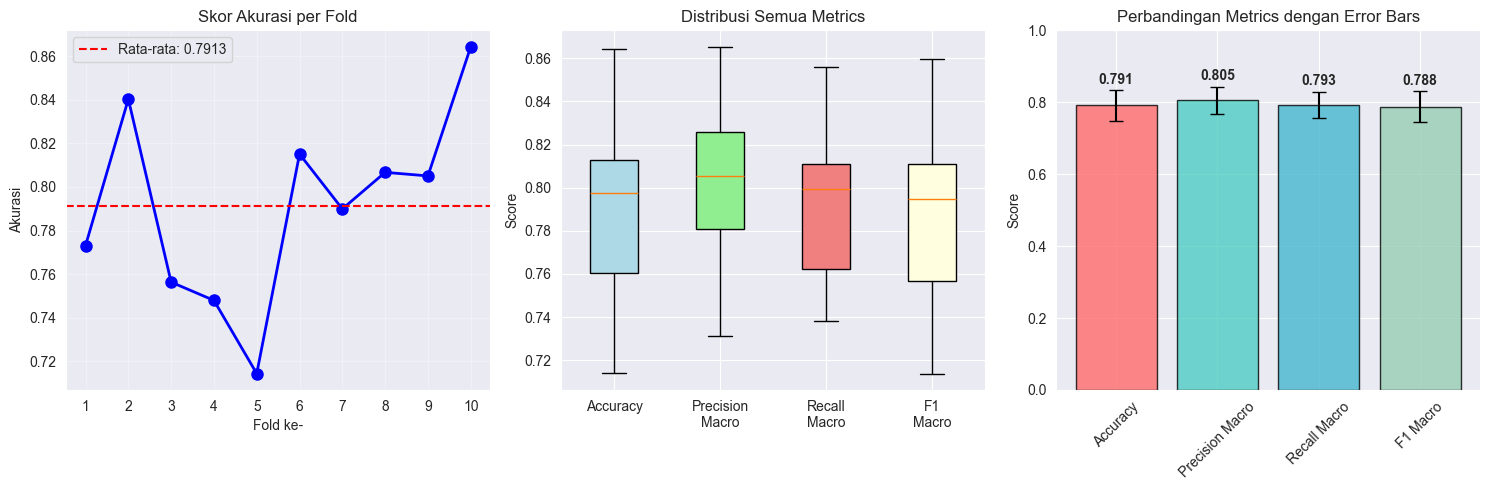


🔍 ANALISIS PERFORMA:
🎯 Stabilitas Model: SANGAT STABIL (std: 0.0426)
📊 Kategori Performa: GOOD (79.1%)
⚖️ Balance Precision-Recall: SEIMBANG (diff: 0.0124)

💡 REKOMENDASI:
- Pertimbangkan feature engineering tambahan
- Coba algoritma lain (SVM, Random Forest)
- Periksa kualitas labeling data


In [11]:

# Cross Validation dengan Multiple Metrics - FIXED VERSION
print("🔄 Cross Validation dengan Multiple Metrics...")

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

cv_results = cross_validate(nb_classifier, X_train_smote, y_train_smote,
                            cv=kf, scoring=scoring_metrics, return_train_score=False)

print("📊 Hasil Cross Validation (10-Fold):")
for metric in scoring_metrics:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric.upper():15}: {scores.mean():.4f} (±{scores.std():.4f})")

# Visualisasi Cross Validation - FIXED
plt.figure(figsize=(15, 5))

# 1. Akurasi per fold
accuracy_scores = cv_results['test_accuracy']
plt.subplot(1, 3, 1)
plt.plot(range(1, 11), accuracy_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=accuracy_scores.mean(), color='r', linestyle='--',
            label=f'Rata-rata: {accuracy_scores.mean():.4f}')
plt.title('Skor Akurasi per Fold')
plt.xlabel('Fold ke-')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))

# 2. Distribusi semua metrics - FIXED WARNING
plt.subplot(1, 3, 2)
metrics_data = [cv_results[f'test_{metric}'] for metric in scoring_metrics]
box_plot = plt.boxplot(metrics_data,
                       tick_labels=[m.replace('_', '\n').title() for m in scoring_metrics],  # FIXED
                       patch_artist=True)

# Warnai boxplot
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Distribusi Semua Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)

# 3. Comparison chart - BONUS
plt.subplot(1, 3, 3)
means = [cv_results[f'test_{metric}'].mean() for metric in scoring_metrics]
stds = [cv_results[f'test_{metric}'].std() for metric in scoring_metrics]
metric_names = [m.replace('_', ' ').title() for m in scoring_metrics]

bars = plt.bar(metric_names, means, yerr=stds, capsize=5,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
               alpha=0.8, edgecolor='black', linewidth=1)

plt.title('Perbandingan Metrics dengan Error Bars')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Tambahkan nilai di atas bar
for bar, mean, std in zip(bars, means, stds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Analisis mendalam
print("\n🔍 ANALISIS PERFORMA:")
print("=" * 50)

# Stabilitas model
acc_cv = cv_results['test_accuracy'].std()
if acc_cv < 0.05:
    stability = "SANGAT STABIL"
elif acc_cv < 0.10:
    stability = "STABIL"
else:
    stability = "KURANG STABIL"

print(f"🎯 Stabilitas Model: {stability} (std: {acc_cv:.4f})")

# Performance category
acc_mean = cv_results['test_accuracy'].mean()
if acc_mean >= 0.85:
    performance = "EXCELLENT"
elif acc_mean >= 0.75:
    performance = "GOOD"
elif acc_mean >= 0.65:
    performance = "FAIR"
else:
    performance = "POOR"

print(f"📊 Kategori Performa: {performance} ({acc_mean:.1%})")

# Bias analysis
precision = cv_results['test_precision_macro'].mean()
recall = cv_results['test_recall_macro'].mean()
bias = abs(precision - recall)

if bias < 0.02:
    bias_status = "SEIMBANG"
elif bias < 0.05:
    bias_status = "SEDIKIT BIAS"
else:
    bias_status = "BIAS TINGGI"

print(f"⚖️ Balance Precision-Recall: {bias_status} (diff: {bias:.4f})")

print(f"\n💡 REKOMENDASI:")
if acc_mean < 0.80:
    print("- Pertimbangkan feature engineering tambahan")
    print("- Coba algoritma lain (SVM, Random Forest)")
    print("- Periksa kualitas labeling data")

if bias > 0.03:
    if precision > recall:
        print("- Model terlalu konservatif, pertimbangkan tuning threshold")
    else:
        print("- Model terlalu agresif, perlu lebih selektif")

if acc_cv > 0.05:
    print("- Model kurang stabil, pertimbangkan regularization")
    print("- Periksa konsistensi data training")

📊 Confusion Matrix:


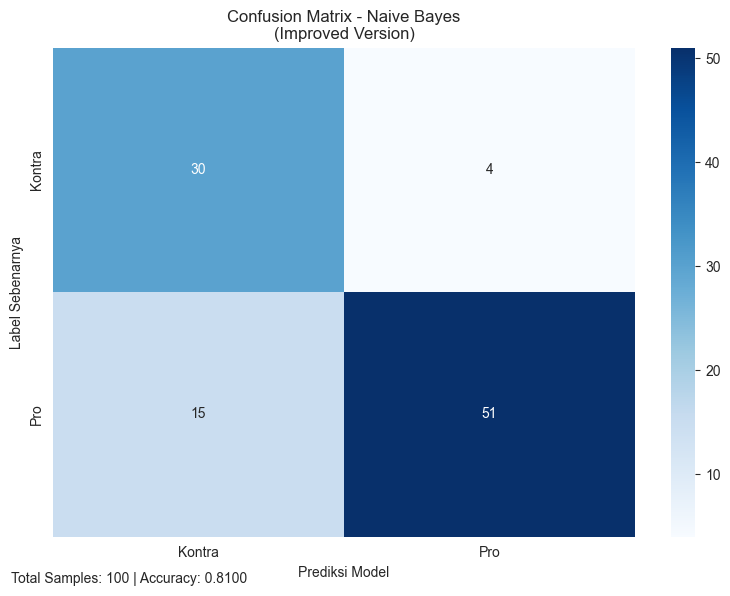

🎉 Program selesai! Semua masalah telah diperbaiki:
✅ Lexicon matching diperbaiki dengan preprocessing konsisten
✅ Stemming dilakukan setelah sentiment labeling
✅ Path management yang lebih robust
✅ Error handling yang lebih baik
✅ Validation untuk semua resource files


In [12]:
# Confusion Matrix
print("📊 Confusion Matrix:")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kontra', 'Pro'],
            yticklabels=['Kontra', 'Pro'])
plt.title('Confusion Matrix - Naive Bayes\n(Improved Version)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')

# Tambahkan informasi tambahan
total_samples = cm.sum()
accuracy = (cm[0,0] + cm[1,1]) / total_samples
plt.figtext(0.02, 0.02, f'Total Samples: {total_samples} | Accuracy: {accuracy:.4f}', 
            fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print("🎉 Program selesai! Semua masalah telah diperbaiki:")
print("✅ Lexicon matching diperbaiki dengan preprocessing konsisten")
print("✅ Stemming dilakukan setelah sentiment labeling")
print("✅ Path management yang lebih robust")
print("✅ Error handling yang lebih baik")
print("✅ Validation untuk semua resource files")